In [102]:
# Core libraries
import pandas as pd
import numpy as np
import json

#preprocessing
from sklearn import set_config
set_config(display = 'diagram', transform_output= "pandas")

# Model selection
from sklearn.metrics import root_mean_squared_log_error, root_mean_squared_error
from sklearn.model_selection import cross_val_score,cross_validate, TimeSeriesSplit
import optuna, optuna_dashboard

# import for linear model
from sklearn.preprocessing import OneHotEncoder  # pour ElasticNet uniquement
from sklearn.pipeline import make_pipeline       # pour ElasticNet uniquement
from sklearn.preprocessing import StandardScaler # pour ElasticNet uniquement
from sklearn.compose import make_column_transformer

#feature selection
from sklearn.inspection import permutation_importance

# models
from sklearn.linear_model import ElasticNet #always like to have a linear model for comparison
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


# Project config
from src.params import *
from src.utils import *
from src.model import *
from src.preprocess.cleaning import *
from src.preprocess.features import *
from src.preprocess.pipeline import *

# Plot configuration
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
import warnings
warnings.filterwarnings("ignore")
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [80]:
df_custom = pd.read_csv("../data/processed/df_processed.csv")
df_14 = pd.read_csv("../data/processed/df_processed_all_lag_14.csv")
df_21 = pd.read_csv("../data/processed/df_processed_all_lag_21.csv")

# I. Baseline

There are several baselines we can use to check our models against. 
1. persistence baseline: y_pred = y_today
2. linear extrapolation: y_pred = y_today + (y_today - y_yesterday)
3. last 3 days average: y_pred 

In order to perform a fair comparison with the models, the baseline score must be calculated using the timeseries splits used for model crossvalidation. 

## I.1 Baseline comparison

In [82]:
#creation time serie split
# val set size: 30 days per city (180 because 6 cities)
# gap between train and val set to avoid trailinf effects: 7 days (42 in total)
tscv = TimeSeriesSplit(n_splits= 5, gap= 42, test_size= 180) # val set of 1month per city #one week gap

### I.1.1 On "custom" dataset

In [94]:
df_custom = df_custom.sort_values(by="date", ascending= True)
y = df_custom.target
X = df_custom.drop(columns= ["target"])

In [95]:
baseline_custom = baseline_crossval(X, y, tscv= tscv)
baseline_custom.columns = ["RMSE_baseline_custom"]
baseline_custom

✅ Baseline calculated and averaged over all folds


,RMSE_baseline_custom
persistence_baseline,0.643943
Extrapolation_baseline,1.033951
Average_baseline,0.630050


### I.1.2 On all_lags_14

In [96]:
df_14 = df_14.sort_values(by="date", ascending= True)
y_14 = df_14.target
X_14 = df_14.drop(columns= ["target"])

In [97]:
baseline_14 = baseline_crossval(X_14, y_14, tscv= tscv)
baseline_14.columns = ["RMSE_baseline_14"]
baseline_14

✅ Baseline calculated and averaged over all folds


,RMSE_baseline_14
persistence_baseline,0.654692
Extrapolation_baseline,1.038010
Average_baseline,0.643283


### I.1.3 On all_lags_21


In [98]:
df_21 = df_21.sort_values(by="date", ascending= True)
y_21 = df_21.target
X_21 = df_21.drop(columns= ["target"])

baseline_21 = baseline_crossval(X_21, y_21, tscv= tscv)
baseline_21.columns = ["RMSE_baseline_21"]
baseline_21

✅ Baseline calculated and averaged over all folds


,RMSE_baseline_21
persistence_baseline,0.665740
Extrapolation_baseline,1.066277
Average_baseline,0.649488


The persistence baseline is one of the two best across all feature engineering approach and is easier to compute so we'll use this one as benchmark. 

## I.2 Baseline visualization

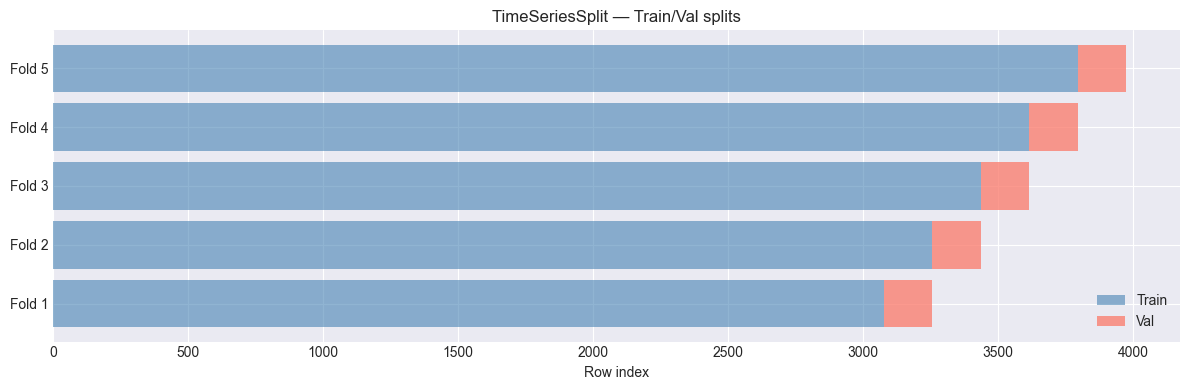

In [99]:
# ── 1. VISUALISATION DES FOLDS (CLAUDE)────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    ax.barh(fold, len(train_idx), left=0, color="steelblue", alpha=0.6, label="Train" if fold == 0 else "")
    ax.barh(fold, len(val_idx), left=train_idx[-1], color="salmon", alpha=0.8, label="Val" if fold == 0 else "")

ax.set_yticks(range(5))
ax.set_yticklabels([f"Fold {i+1}" for i in range(5)])
ax.set_xlabel("Row index")
ax.set_title("TimeSeriesSplit — Train/Val splits")
ax.legend()
plt.tight_layout()

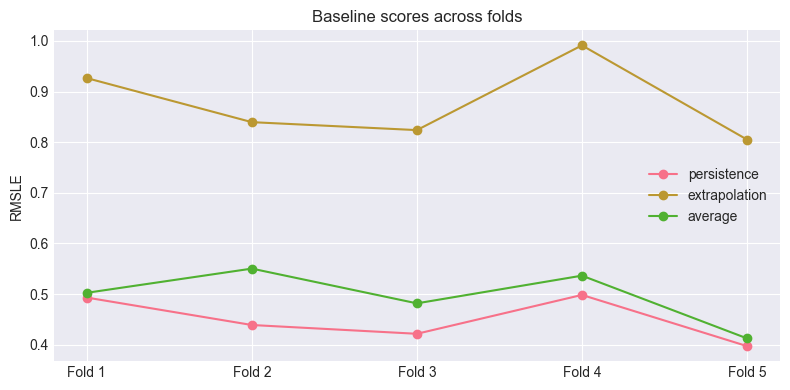

In [100]:
# ── 2. DISTRIBUTION DES SCORES PAR BASELINE ───────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

for name, scores in score_baselines.items():
    ax.plot(range(1, 6), scores, marker="o", label=name)

ax.set_xticks(range(1, 6))
ax.set_xticklabels([f"Fold {i}" for i in range(1, 6)])
ax.set_ylabel("RMSLE")
ax.set_title("Baseline scores across folds")
ax.legend()
plt.tight_layout()

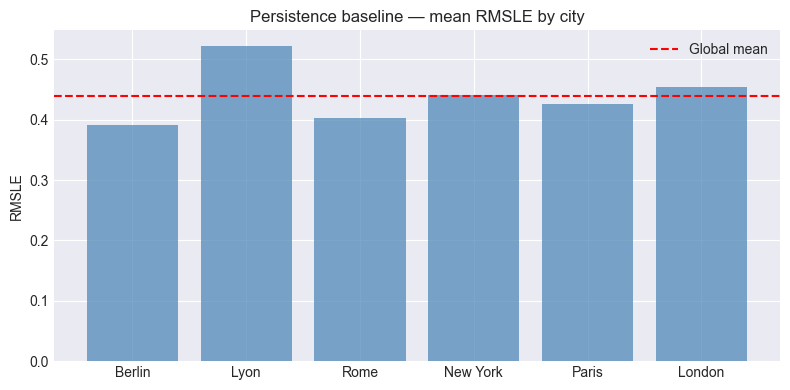

In [101]:
# ── 3. SCORE PAR VILLE — PERSISTENCE BASELINE ─────────────────────────────────
city_scores = {city: [] for city in X["city"].unique()}

for train_idx, val_idx in tscv.split(X):
    X_val_fold = X.iloc[val_idx]
    y_val_fold = y.iloc[val_idx]

    for city in city_scores:
        mask = X_val_fold["city"] == city
        if mask.sum() == 0:
            continue
        y_pred = X_val_fold.loc[mask, "lag_1"]
        y_true = y_val_fold[mask]
        score = root_mean_squared_log_error(np.expm1(y_true), y_pred)
        city_scores[city].append(score)

city_mean_scores = {city: np.mean(scores) for city, scores in city_scores.items()}

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(city_mean_scores.keys(), city_mean_scores.values(), color="steelblue", alpha=0.7)
ax.set_ylabel("RMSLE")
ax.set_title("Persistence baseline — mean RMSLE by city")
ax.axhline(y=np.mean(list(city_mean_scores.values())),
           color="red", linestyle="--", label="Global mean")
ax.legend()
plt.tight_layout()

## I.3 Baseline final score on full train set

In [103]:
baseline_full_custom = baseline_calculation(X= X, y= y, baseline= "persistence")
baseline_full_custom


0.5673330155384547

In [104]:
baseline_full_14 = baseline_calculation(X= X_14, y= y_14, baseline= "persistence")
baseline_full_14

0.5402023661286455

In [105]:
baseline_full_21 = baseline_calculation(X= X_21, y= y_21, baseline= "persistence")
baseline_full_21

0.5482516314676399

# II. model selection

We'll compare the score of different models and check their score. 
here, the model will generate y_pred as a log, so w'ell directly compare y_true and y_pred with RMSE instead of RMSLE. 

In [ ]:
X = X.drop(columns= ["date"])


## II.1 With One Hot Encoding of cities

Using one hot encoder because couldnt handle category in the loop with sklearn crossval for some reason

In [70]:
encoder  = make_column_transformer((OneHotEncoder(sparse_output= False, handle_unknown= "ignore"),
                                   ["city"]),
                                   remainder= "passthrough",
                                   verbose_feature_names_out= False)



estimators = {
    "elastic": make_pipeline(encoder,
                            StandardScaler(),
                            ElasticNet()),
    "xgboost": make_pipeline(encoder, XGBRegressor()),
    "lgbm": make_pipeline(encoder,LGBMRegressor()),
    "catboost": make_pipeline(encoder, CatBoostRegressor())
}


In [71]:
model_scores = []
for model_name, model in estimators.items():
    results = cross_validate(
        model, X, y,
        cv=tscv,
        scoring="neg_root_mean_squared_error",
        return_train_score=False
    )
    model_scores.append({
        "name": model_name,
        "mean_score": -results["test_score"].mean(),
        "std_score": results["test_score"].std(),
        "mean_fit_time": results["fit_time"].mean()
    })

pd.DataFrame(model_scores).set_index("name")


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000460 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2713
[LightGBM] [Info] Number of data points in the train set: 3077, number of used features: 24
[LightGBM] [Info] Start training from score 2.232122
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000320 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2721
[LightGBM] [Info] Number of data points in the train set: 3257, number of used features: 24
[LightGBM] [Info] Start training from score 2.237293
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of test

,mean_score,std_score,mean_fit_time
name,,,
elastic,0.600418,0.100611,0.004881
xgboost,0.406620,0.028961,0.209113
lgbm,0.387092,0.026279,0.543995
catboost,0.383667,0.026701,0.635038


### with handling of categories

Objective: try them with native handling of the city category

we'll need to do the crossval loop by hand using the timeseries split from before

In [79]:
import time
X["city"] = X["city"].astype("category")
models = {"xgboost": lambda: XGBRegressor(enable_categorical= True),
          "lgbm": lambda: LGBMRegressor(),
          "catboost": lambda: CatBoostRegressor(verbose= 0, cat_features= ["city"])
}

model_perf = []

for model_name, model_instance in models.items():

    print(f"testing model {model_name}")
    fold_score = []
    fold_time = []


    for train_idx, val_idx in tscv.split(X):
        X_fold_train, y_fold_train = X.iloc[train_idx], y.iloc[train_idx]
        X_fold_val, y_fold_val = X.iloc[val_idx], y.iloc[val_idx]

        model = model_instance()
        t0 = time.time()
        model.fit(X_fold_train, y_fold_train)
        fold_time.append(time.time() - t0)

        y_fold_pred = model.predict(X_fold_val)
        fold_score.append(root_mean_squared_error(y_fold_val, y_fold_pred))

    model_results = {
        "name": model_name,
        "score": np.mean(fold_score),
        "fit_time": np.mean(fold_time),
        "stability": np.std(fold_score)
    }
    model_perf.append(model_results)

pd.DataFrame(model_perf).set_index("name")


testing model xgboost
testing model lgbm
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000266 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2708
[LightGBM] [Info] Number of data points in the train set: 3077, number of used features: 19
[LightGBM] [Info] Start training from score 2.232122
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000266 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2716
[LightGBM] [Info] Number of data points in the train set: 3257, number of used features: 19
[LightGBM] [Info] Start training from score 2.237293
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000311 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2728
[LightGBM] [Info] Number of data points in the train set: 3437, number of used fe

,score,fit_time,stability
name,,,
xgboost,0.416654,0.213577,0.029201
lgbm,0.384742,0.542253,0.027535
catboost,0.388562,0.951436,0.025936


No clear improvement of native category handling, so we'll use the pipeline with city one hot encoding. 

In [ ]:
def objective_catboost(trial):

    params = {
        "iterations": trial.suggest_int("iterations", 100, 3000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log= True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.6, 1.0),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 50),
        "random_state": 273,
        "verbose": 0,
        "eval_metric": "RMSE",
        "cat_features": ["city"]
    }

    model = CatBoostRegressor(**params)
    score = cross_val_score(model, X, y, cv= tscv, scoring= "root_mean_squared_error", n_jobs= -1)
    return -score.mean()



from optuna.samplers import TPESampler

study_catboost = optuna.create_study(
    direction = "minimize",
    sampler= TPESampler(seed= 273),
    pruner= optuna.pruners.MedianPruner(n_startup_trials= 10, n_warmup_steps= 5)
)

study_catboost.optimize(objective_catboost, n_trials= 100, show_progress_bar= True)

print(f"best params: {study_catboost.best_params}")
print(f"Best score: {study_catboost.best_value}")

optuna.visualization.plot_optimization_history(study_catboost)
